In [1]:
import skimage.io
import numpy as np
import pandas as pd
from scipy.ndimage import shift
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree as KDTree
import copy

from matplotlib.colors import Normalize, ListedColormap, LinearSegmentedColormap

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'

from PIL import ImageColor

from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,skimage,scipy,PIL,cv2"))

Last updated: 2025-06-17T16:07:16.843758-07:00

Python implementation: CPython
Python version       : 3.13.3
IPython version      : 9.3.0

Compiler    : MSC v.1943 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.3
skimage   : 0.25.2
scipy     : 1.14.1
PIL       : 11.2.1
cv2       : 4.10.0



In [2]:
colors_inna_hex = [
    "#F59C62",
    "#D98DC4",
    "#FAE255",
    "#4F9EC4",
    "#F4705A",
    "#A3588D",
    "#84DED8",
    "#7DC899",
    "#C4ECFF",
    "#CCAD42",
    "#FFBDC0",
    "#9C9BDE",
    "#3E8A86",
    "#F7E8B2",
    "#BF6868",
    "#D3DD29",
    "#7271AE",
    "#912A2A",
    "#27598B",
    "#BAC7CC"
]
colors_inna_rbg = [ImageColor.getcolor(c, "RGB") for c in colors_inna_hex]
normed_colors = np.array(colors_inna_rbg)/255

In [3]:
colors_inna_10_hex = [c for i, c in enumerate(colors_inna_hex) if i in [0,2,4,5,6,9,12,17,18,19]]


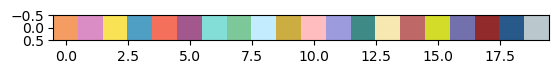

In [4]:
plt.imshow(np.array([colors_inna_rbg]))

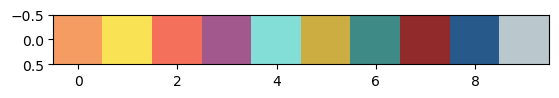

In [5]:
colors_inna_rbg_10 = [c for i, c in enumerate(colors_inna_rbg) if i in [0,2,4,5,6,9,12,17,18,19]]

plt.imshow(np.array([colors_inna_rbg_10]))

In [6]:
colors_inna_rbg_10

[(245, 156, 98),
 (250, 226, 85),
 (244, 112, 90),
 (163, 88, 141),
 (132, 222, 216),
 (204, 173, 66),
 (62, 138, 134),
 (145, 42, 42),
 (39, 89, 139),
 (186, 199, 204)]

In [7]:
pnts_c1 = pd.read_csv('data_tables/points_pos_0_cell1.csv')

In [8]:
pnts_c1

,block,pseudocolor,x,y,s,w
0,1,1,614.701810,1458.302888,1.255165,198.025371
1,1,1,627.111504,1453.579030,1.313266,286.042752
2,1,1,638.102534,1391.032962,1.343114,263.352832
3,1,1,639.335766,1448.677869,1.428329,205.526760
4,1,1,646.429961,1468.136284,1.223632,392.301878
...,...,...,...,...,...,...
112410,10,10,1116.990202,1089.618015,1.717675,410.670072
112411,10,10,1117.713634,1168.632071,1.273087,243.426462
112412,10,10,1117.889038,1150.609084,1.400097,242.328241
112413,10,10,1119.332762,1157.422110,1.907131,482.907994


In [9]:
xmin = int(np.floor(np.min(pnts_c1.x)))
xmax = int(np.ceil(np.max(pnts_c1.x)))
ymin = int(np.floor(np.min(pnts_c1.y)))
ymax = int(np.ceil(np.max(pnts_c1.y)))

In [10]:
pnts_c1.index = range(len(pnts_c1))

In [11]:
pnts_c1

,block,pseudocolor,x,y,s,w
0,1,1,614.701810,1458.302888,1.255165,198.025371
1,1,1,627.111504,1453.579030,1.313266,286.042752
2,1,1,638.102534,1391.032962,1.343114,263.352832
3,1,1,639.335766,1448.677869,1.428329,205.526760
4,1,1,646.429961,1468.136284,1.223632,392.301878
...,...,...,...,...,...,...
112410,10,10,1116.990202,1089.618015,1.717675,410.670072
112411,10,10,1117.713634,1168.632071,1.273087,243.426462
112412,10,10,1117.889038,1150.609084,1.400097,242.328241
112413,10,10,1119.332762,1157.422110,1.907131,482.907994


In [12]:
bcs_c1 = pd.read_csv('data_tables/barcodes_unfiltered_pos_0_cell1_lf7.0_zf1.0_wf0.0_sf0.0_dr0.csv')

bcs_c1.cpath = [eval(cp) for cp in bcs_c1.cpath]

In [13]:
ccoi = bcs_c1.loc[bcs_c1.cc == 85]

In [14]:
print(min(ccoi.x),max(ccoi.x),min(ccoi.y),max(ccoi.y))

824.3924375869558 824.3924375869558 1258.4782662182786 1258.4782662182786


In [15]:
bcs_c1

,gene,gene_number,cpath,cost,x,y,z,cellid,cc,cc_size,pos,cell,lvf,zvf,wf,svf,dr
0,Xdh,262,"[42757, 68065, 79941, 99092]",0.528100,692.805841,1414.132574,0.0,1,1,2,0,1,7.0,1.0,0.0,0.0,0
1,Zfp36l1,269,"[25, 16206, 51055, 70644]",2.882757,695.551489,1390.103161,0.0,1,2,1,0,1,7.0,1.0,0.0,0.0,0
2,Tpm4,239,"[28, 14660, 88427, 96062]",2.217738,701.877312,1376.492374,0.0,1,3,1,0,1,7.0,1.0,0.0,0.0,0
3,Ncl,121,"[14673, 28558, 99108, 106862]",0.916139,711.937835,1414.185600,0.0,1,4,3,0,1,7.0,1.0,0.0,0.0,0
4,Khdrbs1,73,"[38, 68082, 90175, 106869]",3.763393,713.598031,1413.371266,0.0,1,4,3,0,1,7.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6534,Tbrg1,225,"[80542, 90876, 94008, 112144]",1.286384,960.880275,1095.228531,0.0,1,5515,1,0,1,7.0,1.0,0.0,0.0,0
6535,Tbrg1,225,"[80556, 90885, 94014, 112157]",0.195033,966.512011,1151.069183,0.0,1,5516,1,0,1,7.0,1.0,0.0,0.0,0
6536,Tbrg1,225,"[80580, 90912, 94029, 112198]",2.823869,975.877625,1111.036167,0.0,1,5517,1,0,1,7.0,1.0,0.0,0.0,0
6537,Tbrg1,225,"[80620, 90939, 94056, 112239]",3.296353,988.897049,1037.970042,0.0,1,5518,1,0,1,7.0,1.0,0.0,0.0,0


In [16]:
ccoi

,gene,gene_number,cpath,cost,x,y,z,cellid,cc,cc_size,pos,cell,lvf,zvf,wf,svf,dr
159,Ltbp3,80,"[528, 16771, 76222, 100805]",3.113729,824.392438,1258.478266,0.0,1,85,1,0,1,7.0,1.0,0.0,0.0,0


In [17]:
xstart, ystart = 978 , 1063 


xend = xstart + 4
yend = ystart + 5

pnts_c1_roi = pnts_c1.loc[(pnts_c1.x >= xstart) & (pnts_c1.x <= (xend)) & (pnts_c1.y >= ystart) & (pnts_c1.y <= yend)]
pnts_c1_roi.loc[:,"x"] -= xstart
pnts_c1_roi.loc[:,"y"] -= ystart

In [18]:
bcs_c1_roi = bcs_c1.loc[(bcs_c1.x >= xstart) & (bcs_c1.x <= xend) & (bcs_c1.y >= ystart) & (bcs_c1.y <= yend)]
bcs_c1_roi

,gene,gene_number,cpath,cost,x,y,z,cellid,cc,cc_size,pos,cell,lvf,zvf,wf,svf,dr
1175,Prmt1,153,"[35578, 63138, 100206, 111062]",0.433821,978.518400,1065.850981,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1176,Spon2,213,"[32719, 53468, 76813, 103915]",0.614654,978.956946,1064.172527,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1177,Tmbim6,230,"[36939, 58721, 65291, 108919]",0.627834,978.663751,1064.628318,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1179,Zyx,271,"[24283, 41602, 84557, 94530]",3.948952,979.493360,1064.061267,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
3501,Ncl,121,"[15890, 29946, 100203, 107865]",1.486339,978.614419,1063.406762,0.0,1,2582,1,0,1,7.0,1.0,0.0,0.0,0


In [19]:
bcs_c1_roi = bcs_c1.loc[(bcs_c1.x >= xstart) & (bcs_c1.x <= xend) & (bcs_c1.y >= ystart) & (bcs_c1.y <= yend)]
bcs_c1_roi.loc[:,"x"] -= xstart
bcs_c1_roi.loc[:,"y"] -= ystart

In [20]:
bcs_c1_roi

,gene,gene_number,cpath,cost,x,y,z,cellid,cc,cc_size,pos,cell,lvf,zvf,wf,svf,dr
1175,Prmt1,153,"[35578, 63138, 100206, 111062]",0.433821,0.518400,2.850981,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1176,Spon2,213,"[32719, 53468, 76813, 103915]",0.614654,0.956946,1.172527,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1177,Tmbim6,230,"[36939, 58721, 65291, 108919]",0.627834,0.663751,1.628318,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1179,Zyx,271,"[24283, 41602, 84557, 94530]",3.948952,1.493360,1.061267,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
3501,Ncl,121,"[15890, 29946, 100203, 107865]",1.486339,0.614419,0.406762,0.0,1,2582,1,0,1,7.0,1.0,0.0,0.0,0


In [21]:
cps_c1 = pd.read_csv("data_tables/pos0_cell1_cpaths_lvf7.csv")

In [22]:
cps_c1_roi = cps_c1.loc[(cps_c1.x >= xstart) & (cps_c1.x <= xend) & (cps_c1.y >= ystart) & (cps_c1.y <= yend)]
cps_c1_roi.loc[:,"x"] -= xstart
cps_c1_roi.loc[:,"y"] -= ystart

In [23]:
cps_c1_roi.cpath = [eval(cp) for cp in cps_c1_roi.cpath]

C:\Users\jonat\AppData\Local\Temp\ipykernel_15852\1148633643.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cps_c1_roi.cpath = [eval(cp) for cp in cps_c1_roi.cpath]


In [24]:
cps_c1_roi

,gene,gene_number,cpath,cost,x,y
326,Lmna,77,"[24283, 76813, 87111, 108919]",0.405127,0.982894,1.356989
381,Prmt1,153,"[35578, 63138, 100206, 111062]",0.433821,0.518399,2.850981
684,Spon2,213,"[32719, 53468, 76813, 103915]",0.614654,0.956946,1.172527
700,Tmbim6,230,"[36939, 58721, 65291, 108919]",0.627834,0.663751,1.628318
2494,Ncl,121,"[15890, 29946, 100203, 107865]",1.486339,0.614419,0.406762
2949,Lamp1,74,"[33814, 48492, 58721, 69137]",1.704667,0.123258,1.923882
2992,negative_control,1020,"[36939, 48492, 65291, 76813]",1.725021,0.558612,1.513344
6381,negative_control,1270,"[3957, 35578, 63138, 87111]",3.029705,0.617103,2.404026
7256,negative_control,1234,"[3957, 48492, 58721, 87111]",3.329436,0.475658,1.818833
8979,negative_control,788,"[35578, 69137, 73319, 102456]",3.885320,0.541492,2.900271


In [25]:
len(cps_c1_roi)

11

In [26]:
np.sum((cps_c1.x >= xstart) & (cps_c1.x <= xend) & (cps_c1.y >= ystart) & (cps_c1.y <= yend))

np.int64(11)

In [27]:
bcs_c1_roi

,gene,gene_number,cpath,cost,x,y,z,cellid,cc,cc_size,pos,cell,lvf,zvf,wf,svf,dr
1175,Prmt1,153,"[35578, 63138, 100206, 111062]",0.433821,0.518400,2.850981,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1176,Spon2,213,"[32719, 53468, 76813, 103915]",0.614654,0.956946,1.172527,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1177,Tmbim6,230,"[36939, 58721, 65291, 108919]",0.627834,0.663751,1.628318,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1179,Zyx,271,"[24283, 41602, 84557, 94530]",3.948952,1.493360,1.061267,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
3501,Ncl,121,"[15890, 29946, 100203, 107865]",1.486339,0.614419,0.406762,0.0,1,2582,1,0,1,7.0,1.0,0.0,0.0,0


In [28]:
ge_bcs_c1 = bcs_c1.loc[bcs_c1.gene != 'negative_control']
ge_bcs_c1_roi = bcs_c1_roi.loc[bcs_c1_roi.gene != 'negative_control']
nc_bcs_c1_roi = bcs_c1_roi.loc[bcs_c1_roi.gene == 'negative_control']

In [29]:
ge_bcs_c1_roi

,gene,gene_number,cpath,cost,x,y,z,cellid,cc,cc_size,pos,cell,lvf,zvf,wf,svf,dr
1175,Prmt1,153,"[35578, 63138, 100206, 111062]",0.433821,0.518400,2.850981,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1176,Spon2,213,"[32719, 53468, 76813, 103915]",0.614654,0.956946,1.172527,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1177,Tmbim6,230,"[36939, 58721, 65291, 108919]",0.627834,0.663751,1.628318,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1179,Zyx,271,"[24283, 41602, 84557, 94530]",3.948952,1.493360,1.061267,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
3501,Ncl,121,"[15890, 29946, 100203, 107865]",1.486339,0.614419,0.406762,0.0,1,2582,1,0,1,7.0,1.0,0.0,0.0,0


In [30]:
colors_inna_rbg_10

[(245, 156, 98),
 (250, 226, 85),
 (244, 112, 90),
 (163, 88, 141),
 (132, 222, 216),
 (204, 173, 66),
 (62, 138, 134),
 (145, 42, 42),
 (39, 89, 139),
 (186, 199, 204)]

In [31]:
inna_rbg_10_cmap = ListedColormap(np.array(colors_inna_rbg_10)/255, name='inna_rbg10')

In [32]:
bcs_c1_roi

,gene,gene_number,cpath,cost,x,y,z,cellid,cc,cc_size,pos,cell,lvf,zvf,wf,svf,dr
1175,Prmt1,153,"[35578, 63138, 100206, 111062]",0.433821,0.518400,2.850981,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1176,Spon2,213,"[32719, 53468, 76813, 103915]",0.614654,0.956946,1.172527,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1177,Tmbim6,230,"[36939, 58721, 65291, 108919]",0.627834,0.663751,1.628318,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1179,Zyx,271,"[24283, 41602, 84557, 94530]",3.948952,1.493360,1.061267,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
3501,Ncl,121,"[15890, 29946, 100203, 107865]",1.486339,0.614419,0.406762,0.0,1,2582,1,0,1,7.0,1.0,0.0,0.0,0


In [33]:
blk_pc_table = pd.read_csv('../../real_data_processing_workflows/Reed-Solomon_encoded_experiment_workflow/resources/codebooks/block_pseudocolor_table.csv')


In [34]:
blk_pc_table.set_index(['block', 'pseudocolor'], inplace=True)

In [35]:
blocks = [[] for i in range(10)]
max_pix = 0
for block in range(1,11):
    for pseudocolor in range(1,11):
        hyb = blk_pc_table.loc[(block, pseudocolor), "readout hyb"] -1
        ch = blk_pc_table.loc[(block, pseudocolor), "channel"] -1
        img = skimage.io.imread('ims_bg_sub_cropped/' + f'HybCycle_{hyb}_ch{ch}_pos_0.png') #[ystart:(yend+1), xstart:(xend+1)]
        blocks[block-1].append(img)
        img_max = np.max(img)
        if img_max > max_pix:
            max_pix = img_max

for block in range(10):
    for pseudocolor in range(10):
        blocks[block][pseudocolor] = blocks[block][pseudocolor]/max_pix

# Align Images

In [36]:
matched_ref_dots = pd.read_csv('alignment/cross_channel_matched_reference_dots_pos0.csv')

In [37]:
ref_ch = 0

In [38]:
matched_ref_dots = matched_ref_dots.loc[matched_ref_dots.ref_ch == ref_ch]

In [39]:
matched_ref_dots["x_diff"] = matched_ref_dots["ref_x"] - matched_ref_dots["comp_x"]
matched_ref_dots["y_diff"] = matched_ref_dots["ref_y"] - matched_ref_dots["comp_y"]
matched_ref_dots

,ref_x,ref_y,ref_z,ref_int,ref_x.1,ref_y.1,ref_z.1,hyb,comp_x,comp_y,comp_z,comp_int,aligned_x,aligned_y,aligned_z,ref_int.1,ref_ch,comp_ch,x_diff,y_diff
0,1449.926725,20.000076,0.0,9210.356466,1449.926725,20.000076,0.0,1,1449.245454,19.832031,0.0,25221.089953,1450.146285,19.336055,0.0,9210.356466,0,1,0.681271,0.168045
1,1801.189043,103.787634,0.0,3934.042230,1801.189043,103.787634,0.0,1,1800.581303,103.789896,0.0,10112.817788,1801.482133,103.293919,0.0,3934.042230,0,1,0.607740,-0.002262
2,152.702553,50.567884,0.0,14727.241273,152.702553,50.567884,0.0,1,150.531646,50.433243,0.0,45839.649381,151.432477,49.937266,0.0,14727.241273,0,1,2.170907,0.134641
3,1068.808832,55.099914,0.0,6748.543785,1068.808832,55.099914,0.0,1,1067.923390,54.841904,0.0,20287.240522,1068.824220,54.345927,0.0,6748.543785,0,1,0.885442,0.258010
4,1722.787886,71.819406,0.0,9762.707959,1722.787886,71.819406,0.0,1,1722.401754,71.525152,0.0,37618.510252,1723.302585,71.029175,0.0,9762.707959,0,1,0.386132,0.294254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,433.824138,1819.124011,0.0,16132.923379,433.824138,1819.124011,0.0,2,431.742822,1820.777315,0.0,15446.127391,432.746671,1820.690490,0.0,16132.923379,0,2,2.081316,-1.653304
229,1951.978370,1898.900560,0.0,14179.030644,1951.978370,1898.900560,0.0,2,1952.485769,1900.751778,0.0,20316.137266,1953.489618,1900.664953,0.0,14179.030644,0,2,-0.507399,-1.851218
230,1818.623521,449.953068,0.0,10268.142190,1818.623521,449.953068,0.0,2,1818.961420,449.142841,0.0,14190.681871,1819.965269,449.056015,0.0,10268.142190,0,2,-0.337899,0.810227
231,1823.440814,832.861729,0.0,9712.849351,1823.440814,832.861729,0.0,2,1823.813543,832.811671,0.0,11111.083094,1824.817392,832.724845,0.0,9712.849351,0,2,-0.372729,0.050059


In [40]:
ref_diffs = matched_ref_dots.groupby('comp_ch').mean().loc[:,['x_diff', 'y_diff']]
ref_diffs

,x_diff,y_diff
comp_ch,,
1,0.900830,-0.495977
2,1.003849,-0.086826


In [41]:
ch0_offsets = pd.read_csv('alignment/offsets_ch0_pos_0.csv')
ch1_offsets = pd.read_csv('alignment/offsets_ch1_pos_0.csv')
ch2_offsets = pd.read_csv('alignment/offsets_ch2_pos_0.csv')

In [42]:
blk_pc_table2 = pd.read_csv('../../real_data_processing_workflows/Reed-Solomon_encoded_experiment_workflow/resources/codebooks/block_pseudocolor_table.csv')

In [43]:
blk_pc_table2.set_index(["readout hyb", "channel"], inplace=True)

In [44]:
ref_matches = pd.read_csv("alignment/cross_channel_matched_reference_dots_pos0.csv")


matches488 = pd.read_csv("alignment/matches_ch2_pos_0.csv")
matches561 = pd.read_csv("alignment/matches_ch1_pos_0.csv")
matches640 = pd.read_csv("alignment/matches_ch0_pos_0.csv")

matches488.loc[:, "hyb"] += 1
matches561.loc[:, "hyb"] += 1
matches640.loc[:, "hyb"] += 1

matchesDict = {2 : matches488, 1 : matches561, 0 : matches640}

ch_n_matches = ref_matches.groupby("ref_ch").size()
ref_ch = ch_n_matches.index[ch_n_matches.argmax()]


In [45]:
tform_block_pc_dict = dict()
tform_hyb_ch_dict = dict()

for ch in [0,1,2]:
    if ch != ref_ch:
        print("register ch: ", ch)
        for hyb in range(35):
            tform = np.identity(3)

register ch:  1
register ch:  2


In [46]:
offsets488 = pd.read_csv("alignment/offsets_ch2_pos_0.csv")
offsets561 = pd.read_csv("alignment/offsets_ch1_pos_0.csv")
offsets640 = pd.read_csv("alignment/offsets_ch0_pos_0.csv")

offsetsDict = {2 : offsets488, 1 : offsets561, 0 : offsets640}

ref_ch_offsets = offsetsDict[ref_ch]


In [47]:
tform_block_pc_dict = dict()
tform_hyb_ch_dict = dict()

for ch in [0,1,2]:
    if ch != ref_ch:
        print("register ch: ", ch)
        merged = pd.merge(ref_matches.loc[ref_matches.comp_ch == ch], matchesDict[ch], right_on = ["ref_x", "ref_y", "ref_z"], left_on = ["comp_x", "comp_y", "comp_z"])
        for hyb in range(35):
            hyb_merged = merged.loc[merged.hyb_y == hyb]
            tform = np.identity(3)
            tform[0,2] = ref_ch_offsets.loc[hyb,'x']
            tform[1,2] = ref_ch_offsets.loc[hyb,'y']

            tform[0,2] += ref_diffs.loc[ch, "x_diff"]
            tform[1,2] += ref_diffs.loc[ch, "y_diff"]
            
            try:
                tform_block_pc_dict[tuple(blk_pc_table2.loc[(hyb,ch+1), ["block", "pseudocolor"]])] = tform
            except:
                pass
            tform_hyb_ch_dict[(hyb,ch+1)] = tform

register ch:  1
register ch:  2


In [48]:
blk_pc_table2

block  pseudocolor Unnamed: 4
readout hyb channel                               
1           1            1            1        NaN
            2            1            2        NaN
2           1            1            3        NaN
3           1            1            4           
4           1            1            5        NaN
...                    ...          ...        ...
34          3           10            6        NaN
32          1           10            7        NaN
33          1           10            8        NaN
32          2           10            9        NaN
34          1           10           10        NaN

[100 rows x 3 columns]

In [49]:
for hyb in ref_ch_offsets.index:
    if hyb in range(34):
        tform = np.identity(3)
        tform[0,2] = ref_ch_offsets.loc[hyb,'x']
        tform[1,2] = ref_ch_offsets.loc[hyb,'y']
        tform_hyb_ch_dict[(hyb,ref_ch)] = tform
        tform_block_pc_dict[tuple(blk_pc_table2.loc[(hyb+1,ref_ch+1), ["block", "pseudocolor"]])] = tform


In [50]:
len(tform_block_pc_dict.keys())

100

In [51]:
blocks = [[] for i in range(10)]
blockxs = [[] for i in range(10)]
blockxe = [[] for i in range(10)]
blockys = [[] for i in range(10)]
blockye = [[] for i in range(10)]

max_pix = 0
for block in range(1,11):
    for pseudocolor in range(1,11):
        hyb = blk_pc_table.loc[(block, pseudocolor), "readout hyb"] -1
        ch = blk_pc_table.loc[(block, pseudocolor), "channel"] -1
        tform = tform_block_pc_dict[(block, pseudocolor)]


        inv_tform = np.linalg.inv(tform[:2, :2])
        blp = np.transpose(np.matmul(inv_tform[:2, :2], np.array([[xstart - tform[0,2]], [ystart - tform[1,2]]])))[0]
        urp = np.transpose(np.matmul(inv_tform[:2, :2], np.array([[xend - tform[0,2]], [yend - tform[1,2]]])))[0]

        xsi = int(np.round(blp[0])) - xmin
        ysi = int(np.round(blp[1])) - ymin
        xei = int(np.round(urp[0])) - xmin
        yei = int(np.round(urp[1])) - ymin
        
        img = skimage.io.imread('ims_bg_sub_cropped/' + f'HybCycle_{hyb}_ch{ch}_pos_0.png')[ysi:(yei+1),xsi:(xei+1)]
        blocks[block-1].append(img)

        blockxs[block-1].append(xsi)
        blockys[block-1].append(ysi)
        blockxe[block-1].append(xei)
        blockye[block-1].append(yei)
        
        img_max = np.max(img)
        if img_max > max_pix:
            max_pix = img_max

for block in range(10):
    for pseudocolor in range(10):
        blocks[block][pseudocolor] = blocks[block][pseudocolor]/max_pix

In [52]:
print(xstart, xend, ystart, yend)

978 982 1063 1068


In [53]:
pnts_c1

,block,pseudocolor,x,y,s,w
0,1,1,614.701810,1458.302888,1.255165,198.025371
1,1,1,627.111504,1453.579030,1.313266,286.042752
2,1,1,638.102534,1391.032962,1.343114,263.352832
3,1,1,639.335766,1448.677869,1.428329,205.526760
4,1,1,646.429961,1468.136284,1.223632,392.301878
...,...,...,...,...,...,...
112410,10,10,1116.990202,1089.618015,1.717675,410.670072
112411,10,10,1117.713634,1168.632071,1.273087,243.426462
112412,10,10,1117.889038,1150.609084,1.400097,242.328241
112413,10,10,1119.332762,1157.422110,1.907131,482.907994


In [54]:
translated_pnts_c1 = copy.deepcopy(pnts_c1)


In [55]:
for block in range(1,11):
    for pc in range(1,11):
        tform_block_pc_dict[(block, pc)]
        translated_pnts_c1.loc[(translated_pnts_c1.pseudocolor == pc) & (translated_pnts_c1.block == block), "x"] += tform[0,2]
        translated_pnts_c1.loc[(translated_pnts_c1.pseudocolor == pc) & (translated_pnts_c1.block == block), "y"] += tform[1,2]

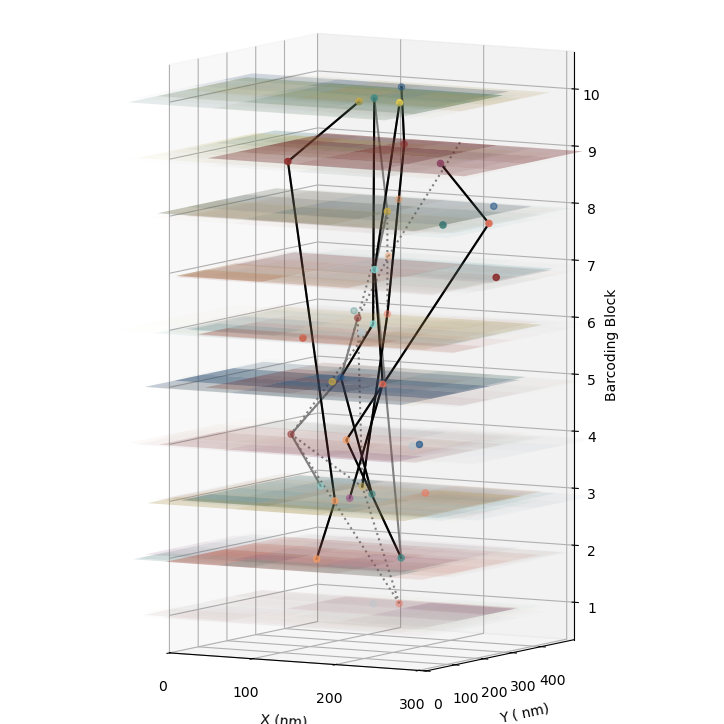

In [56]:
(dots, bcs, dcd, azim, elev, plot_pos) = (translated_pnts_c1, cps_c1_roi, bcs_c1_roi, 300, 7, 1)

fig = plt.figure(figsize=(20,80))

ax = fig.add_subplot(1, 2, plot_pos, projection='3d', azim=azim, elev=elev, proj_type='ortho')
pnts_roi = dots.loc[(dots.x >= (xstart)) & (dots.x <= (xend-0.4)) & (dots.y >= (ystart)) & (dots.y <= (yend-0.3))]

pnts_roi_rm_edge_dots = pnts_roi.loc[(pnts_roi.x - xstart <  3.101) & (pnts_roi.y - ystart < 4)]

ax.scatter(103*(pnts_roi_rm_edge_dots.x - xstart), 103*(pnts_roi_rm_edge_dots.y - ystart), pnts_roi_rm_edge_dots['block'], s = 20,c=pnts_roi_rm_edge_dots['pseudocolor'],cmap = inna_rbg_10_cmap) #, color=dots.pseudocolor)
ax.set_box_aspect((12,12,24))
ax.set_xticks(range(0,100*(xend-xstart),100))
ax.set_yticks(range(0,100*(yend-ystart),100))
ax.set_zticks([1,2,3,4,5,6,7,8,9,10])

ax.set_xlim(0, 103*(xend -xstart -1.0))
ax.set_ylim(0, 103*(yend - ystart))

for b in range(1,11):
    for pc in range(1,11):
        xstart_bpc = blockxs[b-1][pc-1]
        xend_bpc = blockxe[b-1][pc-1]
        ystart_bpc = blockys[b-1][pc-1]
        yend_bpc = blockye[b-1][pc-1]
        for i in range(xend_bpc - xstart_bpc - 1):
            for j in range(yend - ystart - 1):
                tform = tform_block_pc_dict[(b, pc)]
                xblp, yblp = np.matmul(tform[:2, :2],np.array([[xstart_bpc+i], [ystart_bpc+j]]))
                xbrp, ybrp = np.matmul(tform[:2, :2],np.array([[xstart_bpc+i+1], [ystart_bpc+j]]))
                xulp, yulp = np.matmul(tform[:2, :2],np.array([[xstart_bpc+i], [ystart_bpc+j+1]]))
                xurp, yurp = np.matmul(tform[:2, :2],np.array([[xstart_bpc+i+1], [ystart_bpc+j+1]]))
                X = np.array([[xblp[0], xbrp[0]], [xulp[0], xurp[0]]])
                Y = np.array([[yblp[0], ybrp[0]], [yulp[0], yurp[0]]])
                
                X += tform[0,2] - (xstart - xmin)
                Y += tform[1,2] - (ystart - ymin)
                X *= 103
                Y *= 103
                Z = np.zeros(np.shape(X)) + b 
                alph = blocks[b-1][pc-1][j,i]
                ax.plot_surface(X, Y, Z, color=np.array(colors_inna_rbg_10[pc-1])/255, edgecolor='none', lw=0.5, rstride=8, cstride=8,alpha=alph)

for i, bc in bcs.iterrows():
    cpa = np.array(bc.cpath) -1
    cpa_dots = dots.loc[cpa, :]
    inbnds = all(cpa_dots.x >= xstart) & all(cpa_dots.x <= xend) & all(cpa_dots.y >= (0.5+ystart)) & all(cpa_dots.y <= yend)
    if inbnds:
        if bc.gene == 'negative_control':
            ax.plot(103*(dots.loc[cpa,"x"]-xstart), 103*(dots.loc[cpa, "y"]-ystart), dots.loc[cpa, "block"], color="gray", linestyle=':', linewidth =1.5)
        else:
            ax.plot(103*(dots.loc[cpa,"x"]-xstart), 103*(dots.loc[cpa, "y"]-ystart), dots.loc[cpa, "block"], color="gray", linewidth =1.5)
    else:
        None
    

for i, bc in dcd.iterrows():
    cp = bc.cpath
    cpa = np.array(cp) -1
    cpa_dots = dots.loc[cpa, :]
    inbnds = all(cpa_dots.x >= (xstart)) & all(cpa_dots.x <= (xend)) & all(cpa_dots.y >= ystart) & all(cpa_dots.y <= (yend))
    if inbnds:
        if bc.gene == "negative_control":
            ax.plot(103*(dots.loc[cpa,"x"]-xstart), 103*(dots.loc[cpa, "y"]-ystart), dots.loc[cpa, "block"], color="#8d281e", linewidth = 1.5)
        else:
            ax.plot(103*(dots.loc[cpa,"x"]-xstart), 103*(dots.loc[cpa, "y"]-ystart), dots.loc[cpa, "block"], color="black", linewidth = 1.5)
    else:
        None


ax.set_zlabel("Barcoding Block")
ax.set_xlabel("X (nm)")
ax.set_ylabel("Y ( nm)")

mpl.rcParams['pdf.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('fig2F.pdf')

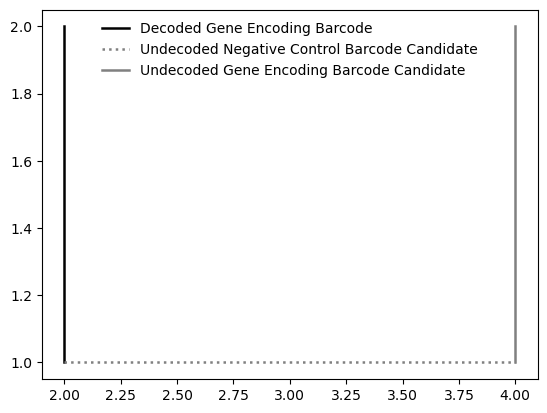

In [57]:
plt.plot([2,2], [1,2], color="black", linewidth = 1.8, label="Decoded Gene Encoding Barcode")
plt.plot([2,4], [1,1], color="gray", linestyle=':', linewidth =1.8, label="Undecoded Negative Control Barcode Candidate")
plt.plot([4,4], [1,2], color="gray", linewidth =1.8, label="Undecoded Gene Encoding Barcode Candidate")


plt.legend(frameon=False)
plt.savefig("Fig2F_legend.pdf")

In [58]:
cps_c1_roi.loc[(cps_c1_roi.x < 2) & (cps_c1_roi.y < 2)]

,gene,gene_number,cpath,cost,x,y
326,Lmna,77,"[24283, 76813, 87111, 108919]",0.405127,0.982894,1.356989
684,Spon2,213,"[32719, 53468, 76813, 103915]",0.614654,0.956946,1.172527
700,Tmbim6,230,"[36939, 58721, 65291, 108919]",0.627834,0.663751,1.628318
2494,Ncl,121,"[15890, 29946, 100203, 107865]",1.486339,0.614419,0.406762
2949,Lamp1,74,"[33814, 48492, 58721, 69137]",1.704667,0.123258,1.923882
2992,negative_control,1020,"[36939, 48492, 65291, 76813]",1.725021,0.558612,1.513344
7256,negative_control,1234,"[3957, 48492, 58721, 87111]",3.329436,0.475658,1.818833
9165,Zyx,271,"[24283, 41602, 84557, 94530]",3.948952,1.493360,1.061267


In [59]:
dots = translated_pnts_c1

In [60]:
pnts_roi = dots.loc[(dots.x >= xstart) & (dots.x <= xend) & (dots.y >= ystart) & (dots.y <= yend)]

In [61]:
bcs_c1_roi

,gene,gene_number,cpath,cost,x,y,z,cellid,cc,cc_size,pos,cell,lvf,zvf,wf,svf,dr
1175,Prmt1,153,"[35578, 63138, 100206, 111062]",0.433821,0.518400,2.850981,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1176,Spon2,213,"[32719, 53468, 76813, 103915]",0.614654,0.956946,1.172527,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1177,Tmbim6,230,"[36939, 58721, 65291, 108919]",0.627834,0.663751,1.628318,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
1179,Zyx,271,"[24283, 41602, 84557, 94530]",3.948952,1.493360,1.061267,0.0,1,749,11,0,1,7.0,1.0,0.0,0.0,0
3501,Ncl,121,"[15890, 29946, 100203, 107865]",1.486339,0.614419,0.406762,0.0,1,2582,1,0,1,7.0,1.0,0.0,0.0,0


In [62]:
pnts_c1

,block,pseudocolor,x,y,s,w
0,1,1,614.701810,1458.302888,1.255165,198.025371
1,1,1,627.111504,1453.579030,1.313266,286.042752
2,1,1,638.102534,1391.032962,1.343114,263.352832
3,1,1,639.335766,1448.677869,1.428329,205.526760
4,1,1,646.429961,1468.136284,1.223632,392.301878
...,...,...,...,...,...,...
112410,10,10,1116.990202,1089.618015,1.717675,410.670072
112411,10,10,1117.713634,1168.632071,1.273087,243.426462
112412,10,10,1117.889038,1150.609084,1.400097,242.328241
112413,10,10,1119.332762,1157.422110,1.907131,482.907994


In [63]:
pnts_c1.loc[np.array([56462, 77304, 99403, 106206]) -1, :]

,block,pseudocolor,x,y,s,w
56461,5,7,791.888243,1163.274438,1.100000,693.117897
77303,7,6,791.816539,1163.571298,1.515241,683.548532
99402,9,8,792.296174,1163.444015,1.769002,1295.199685
106205,10,5,791.996100,1163.428020,1.417246,458.411093


In [64]:
len(cps_c1_roi)

11

In [65]:
np.sum(cps_c1_roi.gene == 'negative_control')

np.int64(4)

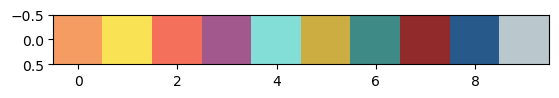

In [66]:
colors_inna_rbg_10 = [c for i, c in enumerate(colors_inna_rbg) if i in [0,2,4,5,6,9,12,17,18,19]]

plt.imshow(np.array([colors_inna_rbg_10]))

In [67]:
block=1
pseudocolor=1
hyb = blk_pc_table.loc[(block, pseudocolor), "readout hyb"] -1
ch = blk_pc_table.loc[(block, pseudocolor), "channel"] -1
blk_pc_table.loc[(block, pseudocolor), "readout hyb"] -1
c1_crop = skimage.io.imread('ims_bg_sub_cropped/' + f'HybCycle_{hyb}_ch{ch}_pos_0.png')

In [68]:
block=1
pc_crops = []
for pseudocolor in range(1,11):
    hyb = blk_pc_table.loc[(block, pseudocolor), "readout hyb"] -1
    ch = blk_pc_table.loc[(block, pseudocolor), "channel"] -1
    blk_pc_table.loc[(block, pseudocolor), "readout hyb"] -1
    c1_crop = skimage.io.imread('ims_bg_sub_cropped/' + f'HybCycle_{hyb}_ch{ch}_pos_0.png')
    pc_crops.append(c1_crop)

In [69]:
import copy

In [70]:
def scale_to_color_vector_wbg(grey_scale_img, rgb_code):
    img_rgb = np.zeros(list(np.shape(grey_scale_img)) + [3])
    for c in range(3):
        img_rgb[:,:,c] = (1-grey_scale_img*(1 -rgb_code[c]/255))
    return img_rgb   

In [71]:
mx = np.max([np.max(gs) for gs in pc_crops])

In [72]:
pc_crops_scaled = [gs/mx for gs in pc_crops]

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
C:\Users\jonat\AppData\Local\Temp\ipykernel_15852\241199218.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.text(475, 520, "5 $\mu$m")


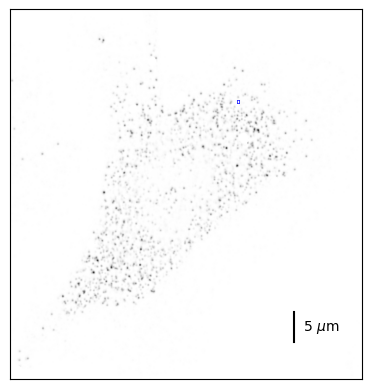

In [73]:
plt.imshow(c1_crop, cmap="Greys")
plt.plot([xstart-xmin, xend-xmin], [ystart-ymin, ystart-ymin], 'b', linewidth=0.5)
plt.plot([xstart-xmin, xend-xmin], [yend-ymin, yend-ymin], 'b', linewidth=0.5)
plt.plot([xend-xmin, xend-xmin], [ystart-ymin, yend-ymin], 'b', linewidth=0.5)
plt.plot([xstart-xmin, xstart-xmin], [ystart-ymin, yend-ymin], 'b', linewidth=0.5)
plt.plot([460,460], [490, 490 + 5 * (1/0.103)], '-k')
plt.text(475, 520, "5 $\mu$m")
plt.tick_params(left = False, bottom = False, labelleft = False, labelbottom=False)
plt.savefig("Fig2D.pdf")

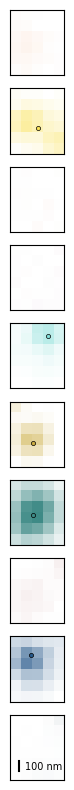

In [74]:
fig, ax = plt.subplots(10,1, figsize=(2,10))
max_int = 0
for pc in range(10):
    if np.max(blocks[9][pc]) > max_int:
        max_int = np.max(blocks[9][pc])

pnts_roi_block9 = pnts_roi.loc[pnts_roi.block==10]
for pc in range(10):
    ax[pc].imshow(scale_to_color_vector_wbg(blocks[9][pc]/max_int, colors_inna_rbg_10[pc]), origin="lower")
    ax[pc].tick_params(left = False, bottom = False, labelleft = False, labelbottom=False)

    pnts_roi_block9_pc = pnts_roi_block9.loc[pnts_roi_block9.pseudocolor == pc+1]
    ax[pc].plot(pnts_roi_block9_pc.x - xstart, pnts_roi_block9_pc.y - ystart, '.', color=colors_inna_10_hex[pc],markeredgecolor='black',markeredgewidth=0.5)

ax[9].plot([0.3,0.3],[0.3,0.3 + 100/103], 'k-')
ax[9].text(0.9, 0.4, "100 nm", size=7)
plt.savefig("Fig2E.pdf")